Accuracy สำหรับ SVM Kernel 'linear': 0.8475
Accuracy สำหรับ SVM Kernel 'poly': 0.8475
Accuracy สำหรับ SVM Kernel 'rbf': 0.8475

Kernel ที่ดีที่สุดคือ: linear ด้วยความแม่นยำ 0.8475


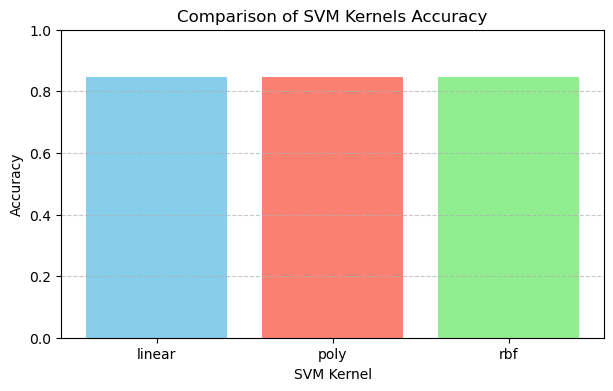

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('data (2) (1).csv')


df.columns = df.columns.str.strip()


df = df.replace('?', np.nan)

df = df.drop(columns=['slope', 'ca', 'thal'], errors='ignore')

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
X = df.drop(columns=['num'])
y = (df['num'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf']
accuracies = {}

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    y_pred = svm_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies[kernel] = acc
    print(f"Accuracy สำหรับ SVM Kernel '{kernel}': {acc:.4f}")

best_kernel = max(accuracies, key=accuracies.get)
print(f"\nKernel ที่ดีที่สุดคือ: {best_kernel} ด้วยความแม่นยำ {accuracies[best_kernel]:.4f}")

plt.figure(figsize=(7, 4))
plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Comparison of SVM Kernels Accuracy')
plt.xlabel('SVM Kernel')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()